<a href="https://colab.research.google.com/github/Kunal-7O7/Machine-Learning-Algorithms/blob/main/RandomForest_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df_ma=sns.load_dataset("titanic")

In [3]:
#Copying the dataset for EDA
df=df_ma.copy()

In [4]:
#Basic EDA on the Dataset

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
#Basic EDA
df.info()

print("-"*50)

df.describe()

print("-"*50)

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
--------------------------------------------------
----------------------------

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
# Removing the Useless features

df=df.drop(["class","who","adult_male","embark_town","deck","alive"],axis=1)

In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [9]:
df["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [10]:
# filling missing values

df["age"]=df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [11]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


In [12]:
for col in ["sex","embarked"]:
  df[col]=df[col].map({"male":1,"female":0,"C":0,"S":2,"Q":1})

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


In [14]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [15]:
x.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,1,22.0,1,0,7.2500,2,False
1,1,0,38.0,1,0,71.2833,0,False
2,3,0,26.0,0,0,7.9250,2,True
3,1,0,35.0,1,0,53.1000,2,False
4,3,1,35.0,0,0,8.0500,2,True


In [16]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [18]:
model=RandomForestClassifier()

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

In [19]:
print("accuracy_score",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))
print("classification_report",classification_report(y_test,y_pred))

accuracy_score 0.8100558659217877
confusion_matrix [[88 17]
 [17 57]]
classification_report               precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [20]:
cm=confusion_matrix(y_test,y_pred)

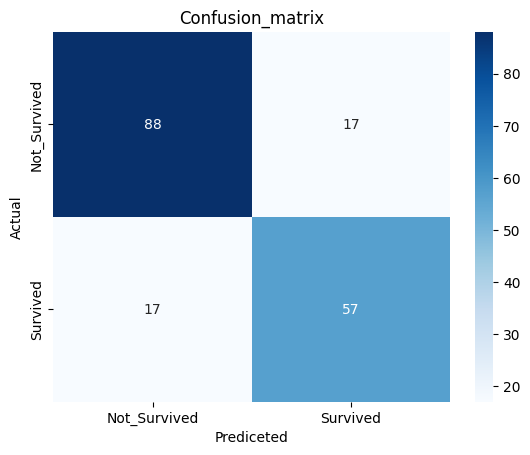

In [21]:
#ploting the cm

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Not_Survived","Survived"],
            yticklabels=["Not_Survived","Survived"]
)
plt.xlabel("Prediceted")
plt.ylabel("Actual")
plt.title("Confusion_matrix")
plt.show()

In [22]:
# features importance
importance = pd.DataFrame({

    "Feature": x.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,sex,0.272517
5,fare,0.268946
2,age,0.251293
0,pclass,0.083005
3,sibsp,0.042013
6,embarked,0.034517
4,parch,0.032473
7,alone,0.015236


<Axes: xlabel='None', ylabel='Importance'>

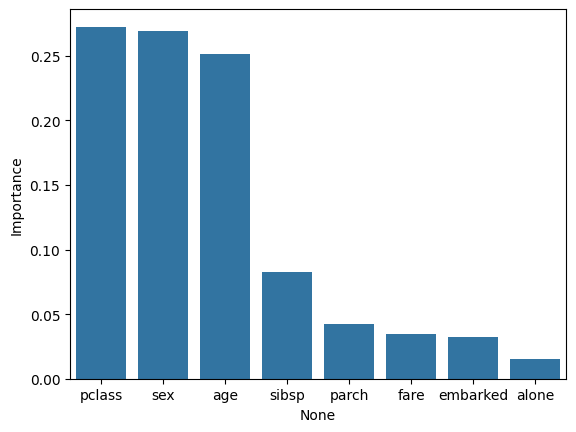

In [23]:
# Ploting the chart

sns.barplot(x=x.columns,y=importance["Importance"])

In [24]:
#HyperParameter Tuning

model1=RandomForestClassifier(max_depth=4,n_estimators=100,
                              min_samples_split=4,min_samples_leaf=2,
                              max_features="sqrt",bootstrap=True,oob_score=True,
                              criterion="gini",random_state=42)

In [25]:
model1.fit(x_train,y_train)

y_pred=model1.predict(x_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("OOB Score:", model1.oob_score_)

Accuracy: 0.8212290502793296
OOB Score: 0.8132022471910112


In [27]:
#Hyperparameter Tuning with gridshearcross validation

from sklearn.model_selection import GridSearchCV,RandomizedSearchCV


In [28]:
param_gird={"n_estimators":[2,4,6,7,10],
            "max_depth":[2,4,5],
            "min_samples_split":[3,5]
            }

In [29]:
grid=GridSearchCV(estimator=RandomForestClassifier(),param_grid=param_gird,cv=5,scoring="accuracy")

In [30]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 4, 5], 'min_samples_split': [3, 5],
                         'n_estimators': [2, 4, 6, 7, 10]},
             scoring='accuracy')

In [31]:
y_pred=grid.predict(x_test)

In [32]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 7}
0.8173643258150302


In [38]:
# Hypermeter Tuning Through RandomisedSearchCV

param_dist={"max_depth":[5,10,15,20],
            "min_samples_split":[4,6,8],
            "min_samples_leaf":[10,12,15]}


for i in range(1,10):
  Rtuning=RandomizedSearchCV(estimator=RandomForestClassifier(),
  param_distributions=param_dist,n_iter=i,cv=5,scoring="accuracy")

  Rtuning.fit(x_train,y_train)

y_pred=Rtuning.predict(x_test)

print(Rtuning.best_params_)
print(Rtuning.best_score_)

{'min_samples_split': 4, 'min_samples_leaf': 10, 'max_depth': 10}
0.8230079779375554


In [43]:
#Cross Validation Score

from sklearn.model_selection import cross_val_score
CV_Score=cross_val_score(model1,x,y,cv=10)

print(CV_Score)
print(CV_Score.mean())


[0.8        0.83146067 0.78651685 0.8988764  0.88764045 0.79775281
 0.82022472 0.76404494 0.85393258 0.84269663]
0.828314606741573
